Hands-On Lab: Using a Pre-trained Transformer       
● Step 1: Load a pre-trained transformer with the Hugging Face pipeline and run it on sample text.      
● Step 2: If the project is text-based, apply the transformer to the project data and compare its metric to the Day 3 LSTM.     
● Step 3: Explain, in Markdown, in one paragraph, how attention differs from an RNN's step-by-step memory.      
● Step 4: Record which architecture (LSTM vs. transformer) will serve as the project's core model and why.      

## processing Data:

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load & inspect:

In [3]:
path = r"..\Data\IMDB Dataset of 50K Movie Reviews\IMDB Dataset.csv"

df = pd.read_csv(path) # header=None because this dataset does not use a normal header row

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
print(df.isnull().sum())
print("")
print("Duplicates:", df.duplicated().sum())

review       0
sentiment    0
dtype: int64

Duplicates: 418


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)
print("Duplicates left:", df.duplicated().sum())

New shape: (49582, 2)
Duplicates left: 0


In [ ]:
print(df.columns)
print ("")

# inspecting label distribution

print(df["sentiment"].value_counts()) 
print ("")

Index(['review', 'sentiment'], dtype='str')

sentiment
positive    24884
negative    24698
Name: count, dtype: int64



In [12]:
# inspecting (fisrt row)

print(df["review"].iloc[0]) # inspecting first review

print("\nLabel:", df["sentiment"].iloc[0]) # first review label


One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

sequence of words → sentiment class

That makes this a `text-sequence classification problem`.

#### Split Dataset:

transformers use a `semi-supervised` approach to learning, so the data will be split into training & testing sets.


In [15]:
from sklearn.model_selection import train_test_split

X = df["review"] # X contains the text the Transformer reads.
y = df["sentiment"] # y contains the correct answer used to evaluate its prediction.


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


In [16]:
print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Train size: 39665
Test size: 9917

Train labels:
sentiment
positive    19907
negative    19758
Name: count, dtype: int64

Test labels:
sentiment
positive    4977
negative    4940
Name: count, dtype: int64


## Transformers:

In [43]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
import torch

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Tokenization:

Transformer works with numbers.     
 So a tokenizer converts text into numbers(called token IDs).

I'll will be using a `pretrained tokenizer` (`DistilBERT`)


**Why use the tokenizer matching the model?**       
Because the pretrained model learned using a specific vocabulary and tokenization method.       
 We should not use an unrelated tokenizer with it.      

In [18]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained( model_name )

c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Masters Computer\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [23]:
# tokenization on the first review

sample_review = X_train.iloc[0]

tokens = tokenizer(
    sample_review,
    max_length = 128, # since review can be quite long, we will limit the number of tokens to 128, so it can be processed in a reasonable time.
    padding = "max_length", # means if it is shorter than 128 tokens, pad it until it reaches 128.
    truncation = True, # means if the review is longer than 128 tokens, keep only the first 128.
    return_tensors = "pt"
    )

In [24]:
# inspect the tokenized output

print(tokens.keys())

print(tokens["input_ids"].shape) # input_ids are the token numbers

print(tokens["attention_mask"].shape) # Suppose the real review only needs 80 tokens, but we force every input to have length 128.
                                                # The remaining positions are padding.
                                                # the mask tells the transformer:  (1 = real token) ,(0 = padding)

KeysView({'input_ids': tensor([[  101,  1045,  2572,  2028,  1997, 15333,  6806, 21927,  1005,  1055,
          9390,  1998,  1045,  2036,  2147,  1999,  2019, 11325,  2729,  2966,
          4322,  1012,  2058,  1996,  2086,  1045,  2031,  2464,  2111,  3280,
          2013, 19610,  4747, 21252,  9597,  2000,  2668,  9099, 20523,  2015,
          1010,  2031,  3230,  3365,  9281,  2006,  2668,  2141, 26835,  2015,
          1010,  1998,  2031,  2464,  2195,  5022,  2468,  5667,  5665,  2013,
         26835,  2015, 10572,  2011,  9099, 25608,  2098,  2668,  1012,  1045,
          2031,  2036,  2657,  2195, 15333,  6806, 21927,  1005,  1055,  9390,
          2108,  2409,  2008,  2027,  2097,  3280,  2065,  2027, 10214,  2668,
          1998,  2044,  2656,  2086,  1999,  1996,  2492,  1045,  2031,  2196,
          2941,  2464,  2009,  4148,  1010,  2975,  1996,  3160,  1010,  1000,
          2003,  2009,  2428, 29205,  2000, 10214,  2668,  9099, 20523,  2015,
          2030,  2003,  1996,

### Model

#### Pretrained DistilBERT sentiment model

we are not training DistilBERT, we are doing :

IMDb reviews        
↓       
pretrained sentiment Transformer        
↓       
predictions     
↓       
compare against IMDb labels     

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
                                                             "distilbert-base-uncased-finetuned-sst-2-english"
                                                         )
'''**Why this model?**

distilbert-base-uncased = the DistilBERT architecture       
finetuned-sst-2-english = it has already been fine-tuned for positive/negative sentiment classification         
'''

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5575.11it/s]


' Why this model?\n\ndistilbert-base-uncased = the DistilBERT architecture\nfinetuned-sst-2-english = it has already been fine-tuned for positive/negative sentiment classification \n'

#### Try with `ONE` review


In [ ]:
sample_review = X_test.iloc[0] # the review we want to test the model on.

tokens = tokenizer(
    sample_review, # since it is one we can pass it directly, but When we have multiple reviews , we will pass them as a list of strings '.list()'
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

In [ ]:
# make a prediction (run the model) 
with torch.no_grad():
    outputs = model(**tokens) # takes the tokenized input and returns the raw class scores (logits)

In [ ]:
print(outputs.logits) # outputs.logits are the raw class scores

tensor([[ 4.7510, -3.8163]])


In [32]:
# To transform outputs.logits into probabilities

probabilities = torch.softmax(outputs.logits , dim=1)

print(probabilities)

tensor([[9.9981e-01, 1.9018e-04]])


In [ ]:
# Then get the predicted class

predicted_class = torch.argmax(probabilities , dim=1).item() 

print("Predicted class:", predicted_class) # 0 = negative, 1 = positive

Predicted class: 0


In [ ]:
label_map = {
    0: "negative",
    1: "positive"
}

print("Predicted sentiment:", label_map[predicted_class]) # Print the predicted sentiment

print("Actual sentiment:", y_test.iloc[0])

Predicted sentiment: negative
Actual sentiment: negative


#### Try with a `small batch` of reviews

 **Only 200 smaples first?**    
   Because Transformer inference is much heavier than a normal neural network.
    
 we can verify the model pipeline without waiting too much.

In [36]:
sample_size = 200

X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

In [ ]:
# tokenize the small batch

batch_tokens = tokenizer(
    X_sample.tolist(), # we use '.list()' to convert the pandas series into a list of strings, to pass it to the tokenizer.
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

print(batch_tokens["input_ids"].shape)
print(batch_tokens["attention_mask"].shape)

# [200, 128] : 200 reviews, each represented by 128 tokens.

torch.Size([200, 128])
torch.Size([200, 128])


In [ ]:
# make a prediction (run the model) 
with torch.no_grad():
    outputs = model(**batch_tokens)

In [40]:
# get the predictions
y_pred = torch.argmax(outputs.logits,dim=1).numpy()


In [41]:
# since actual IMDb labels are strings, convert them too

y_true = y_sample.map({
    "negative": 0,
    "positive": 1
}).to_numpy()

##### Evaluation (Metrics):

In [42]:

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.86


In [44]:

print(classification_report( y_true, y_pred,  target_names=["negative", "positive"],  digits=4) )

              precision    recall  f1-score   support

    negative     0.8468    0.8952    0.8704       105
    positive     0.8764    0.8211    0.8478        95

    accuracy                         0.8600       200
   macro avg     0.8616    0.8581    0.8591       200
weighted avg     0.8609    0.8600    0.8597       200



In [ ]:
cm = confusion_matrix( y_true,y_pred)

print(cm)

[[94 11]
 [17 78]]


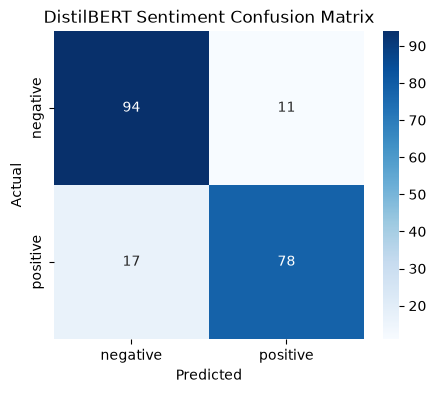

In [47]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Sentiment Confusion Matrix")

plt.show()

## Conclusion:

##### `Pre-trained Transformer Selection`

For the Transformer experiment, the Hugging Face model `distilbert-base-uncased-finetuned-sst-2-english` was selected.

It is a pre-trained DistilBERT model that has already been fine-tuned for binary sentiment classification.      
 The matching Hugging Face tokenizer was used to convert IMDb movie reviews into the token format expected by the model.        

The model was then used for sentiment inference without training a Transformer from scratch.


##### `Attention vs RNN/LSTM Memory`:

An `RNN or LSTM` processes a sequence step by step and carries information forward through a hidden state.      
 This means that information from earlier positions must pass through many intermediate steps before reaching later positions.      

A `Transformer` uses attention instead.     
 Each token can directly examine other tokens in the sequence and assign more importance to the ones that are relevant.     

This makes **Transformers** `better at capturing long-range relationships` because information does not need to travel through every previous time step.  

**Attention** also `allows sequence positions to be processed` more in `parallel`, while RNNs and LSTMs are inherently sequential.


##### `Core Model Decision`:

The pretrained `DistilBERT Transformer` successfully demonstrated how attention can be used for text classification, but it will not be selected as the core model for the ECG heartbeat project.

The project dataset contains numerical `time-series ECG signals`, while DistilBERT is designed for natural-language text.

For this project, the `LSTM` is more appropriate because it is designed to process ordered sequential data and can model changes in the ECG signal across time steps.

Therefore, the Transformer experiment is used to demonstrate the attention mechanism, while the `LSTM remains the more suitable architecture for the ECG classification task`.
